# German Credit Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 2

## Read and Process Data

In [2]:
import pandas as pd
df_ = pd.read_csv('data/german_credit/german_credit_data.csv')
df = df_.copy()

target_name = 'Risk'
target = df[target_name].replace({'good': 0, 'bad': 1})

df['Risk'] = target


C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_40232\4186957327.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target = df[target_name].replace({'good': 0, 'bad': 1})


In [3]:
# Initialize a label encoder
label_encoder = LabelEncoder()
label_mappings = {}


# Convert categorical columns to numerical representations using label encoding
for column in df.columns:
    if column is not target_name and df[column].dtype == 'object':
        # Handle missing values by filling with a placeholder and then encoding
        df[column] = df[column].fillna('Unknown')
        df[column] = label_encoder.fit_transform(df[column])
        label_mappings[column] = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))


# For columns with NaN values that are numerical, we will impute them with the median of the column
for column in df.columns:
    if df[column].isna().any():
        median_val = df[column].median()
        df[column].fillna(median_val, inplace=True)

# Display the first few rows of the transformed dataframe
df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,0
1,22,0,2,1,1,2,5951,48,5,1
2,49,1,1,1,1,0,2096,12,3,0
3,45,1,2,0,1,1,7882,42,4,0
4,53,1,2,0,1,1,4870,24,1,1


## Model Training

In [4]:
import os
# True 表示重新训练模型 False 表示加载已有模型
RETRAIN_MODEL = False  
REGENERATE_Y_TARGET = False
REGENERATE_X_INIT = False

X_INIT_PATH = "saved_models/credit_X_init.pt"
MODEL_PATH = "saved_models/credit_blackbox_model.pth"
FACTUAL_PATH = "saved_models/credit_factual_sample.pt"
Y_TARGET_PATH = "saved_models/credit_y_target.pt"
# 创建保存目录
os.makedirs("saved_models", exist_ok=True)

In [5]:
features = [
    'Age', 
    'Sex', 
    'Job', 
    'Housing', 
    'Saving accounts', 
    'Checking account',
    'Credit amount', 
    'Duration', 
    'Purpose', 
]

df_X = df[features].copy()
df_y = target

In [6]:
seed = 42

np.random.seed(seed)  # for reproducibility


# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

# Initialize the model, loss function, and optimizer
model = BlackBoxModel(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# # Training loop
# num_epochs = 300
# for epoch in range(num_epochs):
#     # Forward pass
#     outputs = model(X_train_tensor)
#     loss = criterion(outputs, y_train_tensor)
    
#     # Backward pass and optimization
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

# # Evaluate on test set
# model.eval()
# with torch.no_grad():
#     test_outputs = model(X_test_tensor)
#     test_loss = criterion(test_outputs, y_test_tensor)

#     # Convert outputs to binary using 0.5 as threshold
#     y_pred_tensor = (test_outputs > 0.5).float()
#     correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
#     accuracy = correct_predictions / y_test_tensor.shape[0]
if RETRAIN_MODEL:
    print("🔁 Training model from scratch...")

    # 训练 loop
    num_epochs = 300
    for epoch in range(num_epochs):
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 测试
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)

        y_pred_tensor = (test_outputs > 0.5).float()
        correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
        accuracy = correct_predictions / y_test_tensor.shape[0]
        print(f"✅ Final Test Accuracy: {accuracy.item():.4f}")

    # 保存模型
    torch.save(model.state_dict(), MODEL_PATH)

    # 保存解释用样本（固定 factual）
    sample_num = 50
    indice = (X_test.sample(sample_num, random_state=42)).index
    df_explain = X_test.loc[indice]
    torch.save(df_explain, FACTUAL_PATH)
    print("✅ Model and factual sample saved.")

else:
    print("📦 Loading model and fixed factual sample...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
    df_explain = torch.load(FACTUAL_PATH)
    print("✅ Loaded.")

# accuracy.item()

📦 Loading model and fixed factual sample...
✅ Loaded.


## Counterfactual Explanation

In [7]:
sample_num = 50
delta = 0.1
alpha = 0.05
N=10
explain_columns = [
    'Age', 
    'Sex', 
    'Job', 
    'Housing', 
    'Saving accounts', 
    'Checking account',
    'Credit amount', 
    'Duration', 
    'Purpose', 
]

indice = (X_test.sample(sample_num)).index

df_explain = X_test.loc[indice]

# 加载或生成 y_target
if REGENERATE_Y_TARGET:
    sample_num = df_explain.shape[0]
    y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))
    torch.save(y_target, Y_TARGET_PATH)
    print("✅ Regenerated and saved y_target.")
else:
    y_target = torch.load(Y_TARGET_PATH)
    print("📦 Loaded y_target.")
# y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))


# X = X_test.loc[indice].values
y = model(torch.FloatTensor(df_explain.values))

if REGENERATE_X_INIT:
    noise = torch.randn_like(torch.FloatTensor(df_explain.values)[:, [df_explain.columns.get_loc(c) for c in explain_columns]]) * 0.01
    X_init = torch.FloatTensor(df_explain.values).clone()
    X_init[:, [df_explain.columns.get_loc(c) for c in explain_columns]] += noise
    torch.save(X_init, X_INIT_PATH)
else:
    X_init = torch.load(X_INIT_PATH)


y_true = y_test.loc[indice]

📦 Loaded y_target.


In [8]:
category = [
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose',
]

continuous = [
    'Age',
    'Credit amount',
    'Duration',
    'Risk'
]

categorical_columns = [
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose',
]
continuous_columns = [
    'Age',
    'Credit amount',
    'Duration',
]


In [9]:
import os
import math
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = f"training_plots_credit/Result_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

def optimization_callback(iteration):

    X_factual_standardized = explainer.X_prime.detach().cpu().numpy()
    X_counterfactual_standardized = explainer.X.detach().cpu().numpy()

    y_factual = explainer.model(explainer.X_prime).detach().numpy()
    y_counterfactual = explainer.model(explainer.X).detach().numpy()

    X_factual_original = X_factual_standardized * std.values + mean.values
    X_counterfactual_original = X_counterfactual_standardized * std.values + mean.values


    df_factual = pd.DataFrame(X_factual_original, columns=explain_columns)
    df_counterfactual = pd.DataFrame(X_counterfactual_original, columns=explain_columns)


    dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
    def recovering_types(df_to_recover, dtype_dict):
        for k, v in dtype_dict.items():
            if k in df_to_recover.columns:
                if v.startswith('int'):
                    df_to_recover[k] = df_to_recover[k].round().astype(v)
                else:
                    df_to_recover[k] = df_to_recover[k].astype(v)
        return df_to_recover

    df_factual = recovering_types(df_factual, dtype_dict)
    df_counterfactual = recovering_types(df_counterfactual, dtype_dict)


    df_factual['Risk'] = y_factual
    df_counterfactual['Risk'] = y_counterfactual


    all_features = explain_columns + ['Risk']
    num_features = len(all_features)


    num_cols = 3
    num_rows = math.ceil(num_features / num_cols)
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(6 * num_cols, 6 * num_rows))

    axes = np.array(axes).reshape(-1)


    for i, feature in enumerate(all_features):
        ax = axes[i]
        factual_values = df_factual[feature]
        counterfactual_values = df_counterfactual[feature]

        if feature in category:
            bins = np.arange(factual_values.min(), factual_values.max() + 2)
            width = 0.35

            ax.bar(bins[:-1] - width / 2, np.histogram(factual_values, bins=bins)[0],
                   width=width, alpha=0.7, label='Fact.', color='blue', edgecolor='black')
            ax.bar(bins[:-1] + width / 2, np.histogram(counterfactual_values, bins=bins)[0],
                   width=width, alpha=0.7, label='C.Fact.', color='red', edgecolor='black')
        elif feature == 'Risk':
            factual_sorted = np.sort(df_factual['Risk'])
            counterfactual_sorted = np.sort(df_counterfactual['Risk'])

            quantiles_factual = np.linspace(0, 1, len(factual_sorted))
            quantiles_counterfactual = np.linspace(0, 1, len(counterfactual_sorted))

            ax.plot(factual_sorted, quantiles_factual, label="Factual", color='blue')
            ax.plot(counterfactual_sorted, quantiles_counterfactual, label="Counterfactual", color='red')

            if len(y_target) == len(factual_sorted):
                target_sorted = np.sort(y_target)
                quantiles_target = np.linspace(0, 1, len(target_sorted))
                ax.plot(target_sorted, quantiles_target, label="Target", color='black', linestyle='--')

            ax.set_title('Risk')
            ax.set_xlabel('Risk Value')
            ax.set_ylabel('Quantiles')
        else:
            factual_sorted = np.sort(factual_values)
            counterfactual_sorted = np.sort(counterfactual_values)
            quantiles_factual = np.linspace(0, 1, len(factual_sorted))
            quantiles_counterfactual = np.linspace(0, 1, len(counterfactual_sorted))

            ax.plot(factual_sorted, quantiles_factual, label="Factual", color='blue')
            ax.plot(counterfactual_sorted, quantiles_counterfactual, label="Counterfactual", color='red')

        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel("Quantiles")
        ax.legend()


    for j in range(i + 1, len(axes)):
        axes[j].axis('off')


    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    fig.suptitle(f'Iteration = {iteration}', fontsize=28)

    filename = os.path.join(output_dir, f'iteration_{iteration}.png')
    plt.savefig(filename)
    plt.close()

        # ✅ 每轮都保存 final 和 best 的 Q、X、y
    if hasattr(explainer, "final_Q") and hasattr(explainer, "best_Q"):

        # 保存当前轮 final_Q
        with open(os.path.join(output_dir, "final_Q.txt"), "w") as f:
            f.write(f"Iteration: {iteration}\n")
            f.write(f"final_Q: {explainer.final_Q}\n")

        # 保存最优轮次的 best_Q
        if hasattr(explainer, "best_Q") and explainer.best_Q is not None:
            best_iter = getattr(explainer, "best_iter", "unknown")
            with open(os.path.join(output_dir, "best_Q.txt"), "w") as f:
                f.write(f"Best Iteration: {best_iter}\n")
                f.write(f"best_Q: {explainer.best_Q}\n")


        # -------- Save final X/Y --------
        X_final_std = explainer.final_X.detach().cpu().numpy()
        X_final_orig = X_final_std * std.values + mean.values
        df_final_X = pd.DataFrame(X_final_orig, columns=explain_columns)
        df_final_X = recovering_types(df_final_X, dtype_dict)
        df_final_X.to_csv(os.path.join(output_dir, "final_X.csv"), index=False)

        y_final = explainer.final_y.detach().cpu().numpy()
        df_final_y = pd.DataFrame(y_final, columns=["Risk"])
        df_final_y.to_csv(os.path.join(output_dir, "final_y.csv"), index=False)

        # -------- Save best X/Y --------
        X_best_std = explainer.best_X.detach().cpu().numpy()
        X_best_orig = X_best_std * std.values + mean.values
        df_best_X = pd.DataFrame(X_best_orig, columns=explain_columns)
        df_best_X = recovering_types(df_best_X, dtype_dict)
        df_best_X.to_csv(os.path.join(output_dir, "best_X.csv"), index=False)

        y_best = explainer.best_y.detach().cpu().numpy()
        df_best_y = pd.DataFrame(y_best, columns=["Risk"])
        df_best_y.to_csv(os.path.join(output_dir, "best_y.csv"), index=False)

        # print(f"✅ Iter {iteration}: Saved final & best Q, X, Y to {output_dir}")




In [10]:
import os
import math
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# dce.py
from explainers.dce import DistributionalCounterfactualExplainer

explainer = DistributionalCounterfactualExplainer(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    categorical_columns=categorical_columns,
    continuous_columns=continuous_columns,
    y_target=y_target, 
    X_init=X_init,
    lr=1e-1, 
    n_proj=N,
    delta=delta
)

explainer.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3, callback=optimization_callback) 

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.12532972796679592
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q = 0.022951500490307808, term1 = 0.14301465451717377, term2 = 0.022951500490307808
INFO:root:U_1-Qu_upper=0.3774470771851521, U_2-Qv_upper=0.09355455642621349
INFO:root:eta=0.8490420036576991, l=0.278, r=1
INFO:root:Iter 2: Q = 0.0034192693419754505, term1 = 0.011744122952222824, term2 = 0.0019391265232115984
INFO:root:U_1-Qu_upper=0.42353588064778624, U_2-Qv_upper=0.24622928250637863
INFO:root:eta=0.7345673502449918, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q = 0.002035116543993354, term1 = 0.0019185356795787811, term2 = 0.0020772425923496485
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.24736612315785694
INFO:root:eta=0.7729781714522039, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q = 0.0010310388170182705, term1 = 0.0011048191227018833, term2 = 0.0010093696182593703
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.2576085919912896
IN

In [11]:
# import os
# import math
# from datetime import datetime
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd


# from explainers.dce_mc import DistributionalCounterfactualExplainer

# explainer = DistributionalCounterfactualExplainer(
#     model=model, 
#     df_X=df_explain, 
#     explain_columns=explain_columns,
#     categorical_columns=categorical_columns,
#     continuous_columns=continuous_columns,
#     y_target=y_target, 
#     X_init=X_init,
#     lr=1e-1, 
#     n_proj=10,
#     delta=delta)

# explainer.optimize_mc_sampling(
#     U_1=0.5, 
#     U_2=0.3, 
#     l=0.2, 
#     r=1, 
#     max_iter=100, 
#     num=10, 
#     kappa=0.02, 
#     bootstrap=True, 
#     callback=None,
#     top_k=3
# )

In [12]:
# import os
# import math
# from datetime import datetime
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# from explainers.dce_genetic import DistributionalCounterfactualExplainer

# explainer = DistributionalCounterfactualExplainer(
#     model=model, 
#     df_X=df_explain, 
#     explain_columns=explain_columns,
#     categorical_columns=categorical_columns,
#     continuous_columns=continuous_columns,
#     y_target=y_target, 
#     X_init=X_init,
#     lr=1e-1, 
#     n_proj=10,
#     delta=delta)

# explainer.optimize_genetic(
#     U_1=0.5, 
#     U_2=0.3, 
#     l=0.2, 
#     r=1, 
#     max_iter=100, 
#     num=10, 
#     kappa=0.02, 
#     bootstrap=True, 
#     callback=optimization_callback,
#     top_k=3
# )

In [13]:
# if no feasible solution is found but we still want to check the result:
# explainer.best_X = explainer.X 

In [14]:
X_s = explainer.best_X[:, explainer.explain_indices].clone()
X_t = explainer.X_prime.clone()

In [15]:
np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())

0.0838739784033893

In [16]:
explainer.swd.distance_interval(X_s, X_t, delta=delta, alpha=alpha)

e:\desktop\distributional-counterfactual-explanation-main\explainers\distances.py:303: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
e:\desktop\distributional-counterfactual-explanation-main\explainers\distances.py:304: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32)
e:\desktop\distributional-counterfactual-explanation-main\explainers\distances.py:329: RuntimeWarning: invalid value encountered in power
  return np.power(SW_lower, 1 / r), np.power(SW_upper, 1 / r)


(0.0, nan)

In [17]:
factual_X = df[df_X.columns].loc[indice].copy()
counterfactual_X = pd.DataFrame(explainer.best_X.detach().numpy() * std[df_X.columns].values + mean[df_X.columns].values, columns=df_X.columns)

dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X.columns:
        if v[:3] == 'int':
            counterfactual_X[k] = counterfactual_X[k].round().astype(v)
        else:
            counterfactual_X[k] = counterfactual_X[k].astype(v)

factual_y = pd.DataFrame(y.detach().numpy(),columns=[target_name], index=factual_X.index)
counterfactual_y = pd.DataFrame(explainer.y.detach().numpy(),columns=[target_name], index=factual_X.index)

In [18]:
# Now, reverse the label encoding using the label_mappings
for dft in [factual_X, counterfactual_X]:
    for column, mapping in label_mappings.items():
        if column in dft.columns:
            # Invert the label mapping dictionary
            inv_mapping = {v: k for k, v in mapping.items()}
            # Map the encoded labels back to the original strings
            dft[column] = dft[column].map(inv_mapping)

In [19]:
factual = factual_X
counterfactual = counterfactual_X

factual[target_name] = factual_y
counterfactual[target_name] = counterfactual_y

In [20]:
factual_X.head(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
436,23,male,1,rent,quite rich,Unknown,660,6,repairs,0.000002
899,42,male,2,own,little,little,4153,18,furniture/equipment,0.301129
346,23,male,2,own,little,moderate,882,13,radio/TV,0.758277
60,27,male,2,own,little,moderate,1391,9,business,0.545755
867,42,male,2,own,little,Unknown,3331,12,furniture/equipment,0.007363


In [21]:
counterfactual_X.head(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,24,male,1,rent,quite rich,Unknown,876,7,repairs,NaN
1,37,male,2,own,Unknown,little,2320,19,radio/TV,NaN
2,27,male,2,own,little,rich,2528,9,radio/TV,NaN
3,28,male,2,own,little,moderate,2593,5,NaN,NaN
4,42,male,2,own,little,Unknown,3119,12,furniture/equipment,NaN


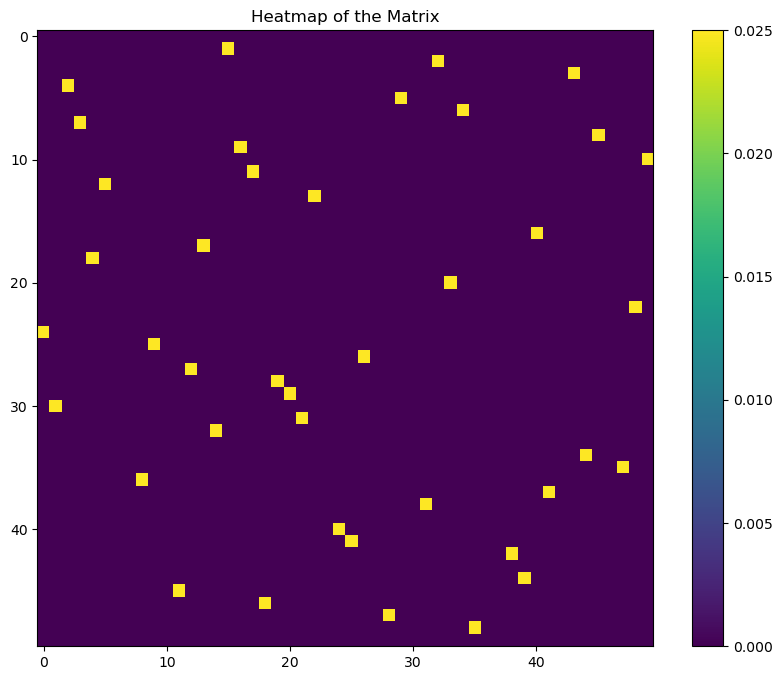

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Sample matrix for demonstration
matrix = explainer.wd.nu.numpy()

plt.figure(figsize=(10, 8))
plt.imshow(matrix, cmap='viridis')
plt.colorbar()
plt.title("Heatmap of the Matrix")
plt.show()


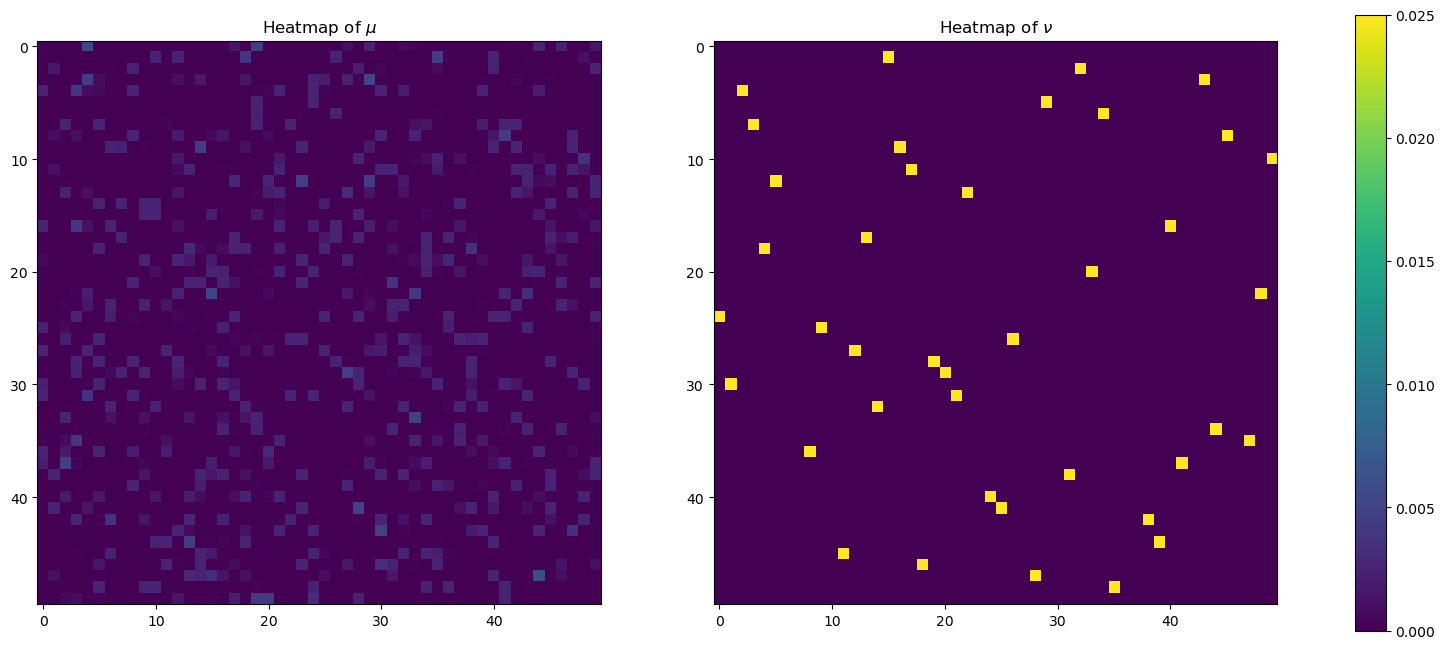

In [23]:
import matplotlib.pyplot as plt

matrix_nu = explainer.wd.nu.detach().numpy()

mu_avg = torch.zeros_like(explainer.swd.mu_list[0])
for mu in explainer.swd.mu_list:
    mu_avg += mu

total_sum = mu_avg.sum()

matrix_mu = mu_avg / total_sum

# Determine the global minimum and maximum values across both matrices
vmin = min(matrix_mu.min(), matrix_nu.min())
vmax = max(matrix_mu.max(), matrix_nu.max())

# Create a figure and a set of subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 8))  # 1 row, 2 columns

# First subplot for matrix_mu
im_mu = axs[0].imshow(matrix_mu, cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title("Heatmap of $\mu$")

# Second subplot for matrix_nu
im_nu = axs[1].imshow(matrix_nu, cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title("Heatmap of $\\nu$")

# Create a colorbar for the whole figure
fig.colorbar(im_mu, ax=axs, orientation='vertical')

# Display the plots
plt.show()